In [4]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

df = pd.read_csv('final_football_data_v2.csv')
df.head()

,Year,League,Team,MarketValue_M_Euro,League_Avg_Attendance,League_Google_Interest,Team_Name
0,2015,Premier League,40,553.50,13855299.0,11.166667,Manchester City
1,2015,Premier League,38,499.35,13855299.0,11.166667,Arsenal
2,2015,Premier League,41,457.85,13855299.0,11.166667,Chelsea FC
3,2015,Premier League,44,439.85,13855299.0,11.166667,Liverpool FC
4,2015,Premier League,44,375.25,13855299.0,11.166667,Liverpool FC


/tmp/ipykernel_4140/675970991.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gap_series = l_df.groupby('Year').apply(calculate_top2_gap)


<Figure size 1400x800 with 0 Axes>

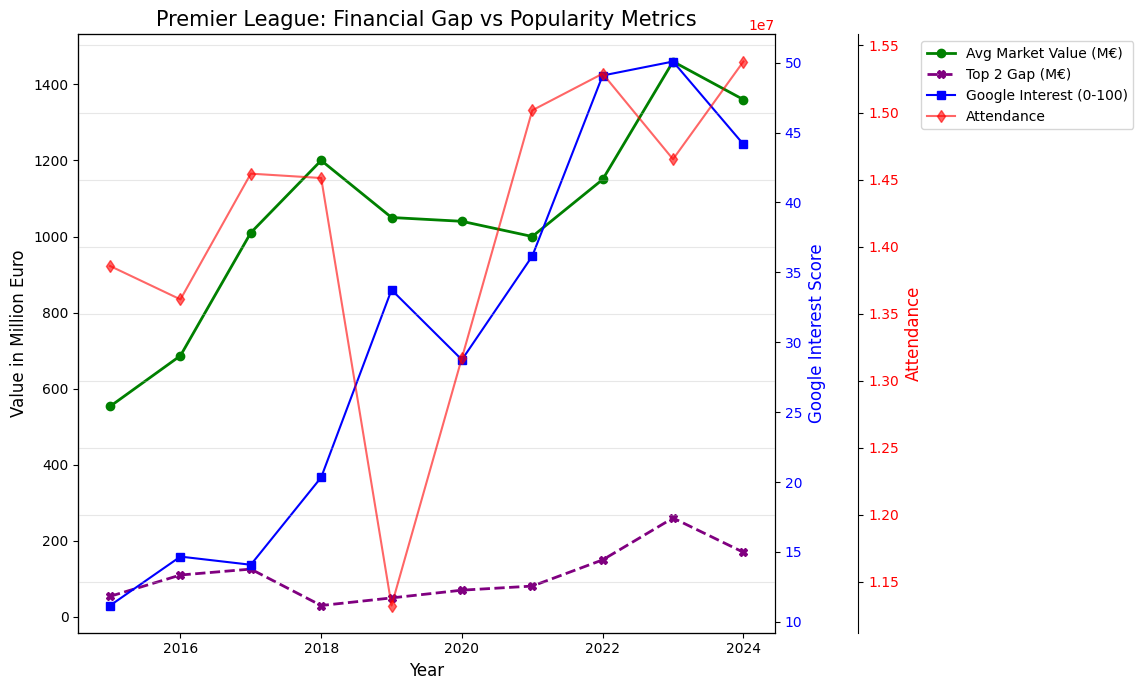

In [6]:
# Premier League
plt.figure(figsize=(14, 8))
league_name = 'Premier League'

l_df = df[df['League'] == league_name].copy()

def calculate_top2_gap(group):
    top2 = group.nlargest(2, 'MarketValue_M_Euro')['MarketValue_M_Euro'].values
    return top2[0] - top2[1] if len(top2) > 1 else 0

gap_series = l_df.groupby('Year').apply(calculate_top2_gap)
yearly_df = l_df.drop_duplicates(subset=['Year']).set_index('Year')
yearly_df['Top2_Gap'] = gap_series

fig, ax1 = plt.subplots(figsize=(12, 7))

ln1 = ax1.plot(yearly_df.index, yearly_df['MarketValue_M_Euro'], color='green', marker='o', linewidth=2, label='Avg Market Value (M€)')
ln2 = ax1.plot(yearly_df.index, yearly_df['Top2_Gap'], color='purple', marker='X', linestyle='--', linewidth=2, label='Top 2 Gap (M€)')
ax1.set_ylabel('Value in Million Euro', fontsize=12)
ax1.set_xlabel('Year', fontsize=12)

ax2 = ax1.twinx()
ln3 = ax2.plot(yearly_df.index, yearly_df['League_Google_Interest'], color='blue', marker='s', label='Google Interest (0-100)')
ax2.set_ylabel('Google Interest Score', color='blue', fontsize=12)
ax2.tick_params(axis='y', labelcolor='blue')

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ln4 = ax3.plot(yearly_df.index, yearly_df['League_Avg_Attendance'], color='red', marker='d', alpha=0.6, label='Attendance')
ax3.set_ylabel('Attendance', color='red', fontsize=12)
ax3.tick_params(axis='y', labelcolor='red')

lns = ln1 + ln2 + ln3 + ln4
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', bbox_to_anchor=(1.2, 1))

plt.title(f'{league_name}: Financial Gap vs Popularity Metrics', fontsize=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4140/590209577.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gap_series = l_df.groupby('Year').apply(calculate_top2_gap)


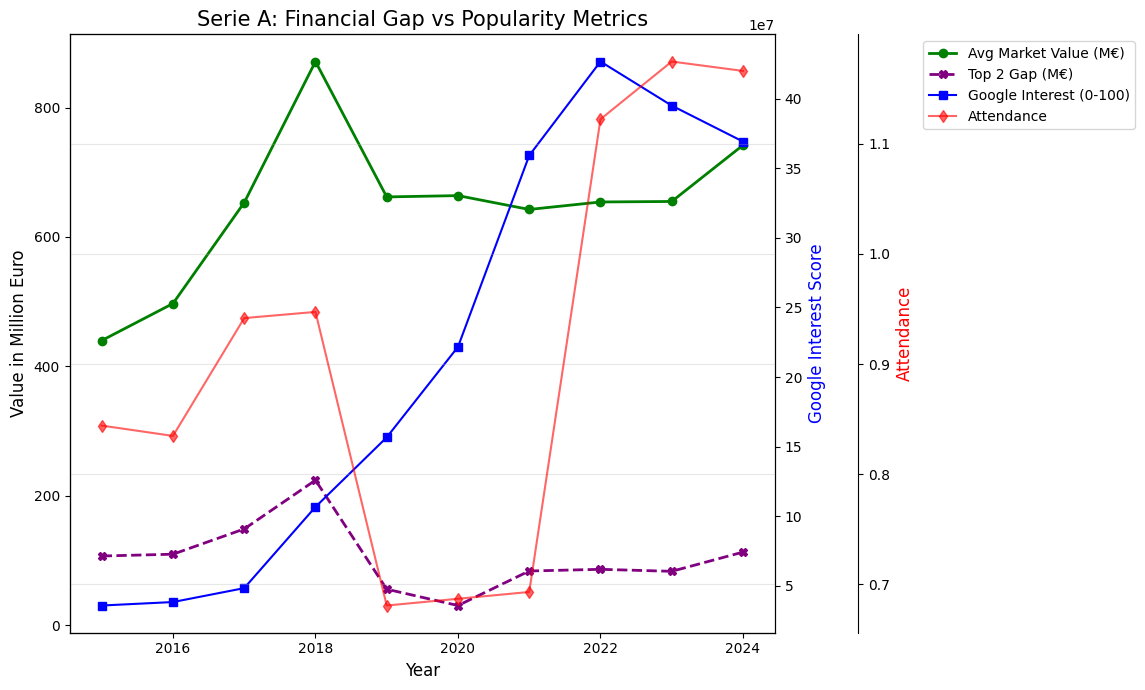

In [7]:
# Serie A
league_name = 'Serie A'
l_df = df[df['League'] == league_name].copy()

def calculate_top2_gap(group):
    top2 = group.nlargest(2, 'MarketValue_M_Euro')['MarketValue_M_Euro'].values
    return top2[0] - top2[1] if len(top2) > 1 else 0

gap_series = l_df.groupby('Year').apply(calculate_top2_gap)
yearly_df = l_df.drop_duplicates(subset=['Year']).set_index('Year')
yearly_df['Top2_Gap'] = gap_series

fig, ax1 = plt.subplots(figsize=(12, 7))
ln1 = ax1.plot(yearly_df.index, yearly_df['MarketValue_M_Euro'], color='green', marker='o', linewidth=2, label='Avg Market Value (M€)')
ln2 = ax1.plot(yearly_df.index, yearly_df['Top2_Gap'], color='purple', marker='X', linestyle='--', linewidth=2, label='Top 2 Gap (M€)')
ax1.set_ylabel('Value in Million Euro', fontsize=12)
ax1.set_xlabel('Year', fontsize=12)

ax2 = ax1.twinx()
ln3 = ax2.plot(yearly_df.index, yearly_df['League_Google_Interest'], color='blue', marker='s', label='Google Interest (0-100)')
ax2.set_ylabel('Google Interest Score', color='blue', fontsize=12)

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ln4 = ax3.plot(yearly_df.index, yearly_df['League_Avg_Attendance'], color='red', marker='d', alpha=0.6, label='Attendance')
ax3.set_ylabel('Attendance', color='red', fontsize=12)

lns = ln1 + ln2 + ln3 + ln4
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', bbox_to_anchor=(1.2, 1))
plt.title(f'{league_name}: Financial Gap vs Popularity Metrics', fontsize=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4140/533455922.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gap_series = l_df.groupby('Year').apply(calculate_top2_gap)


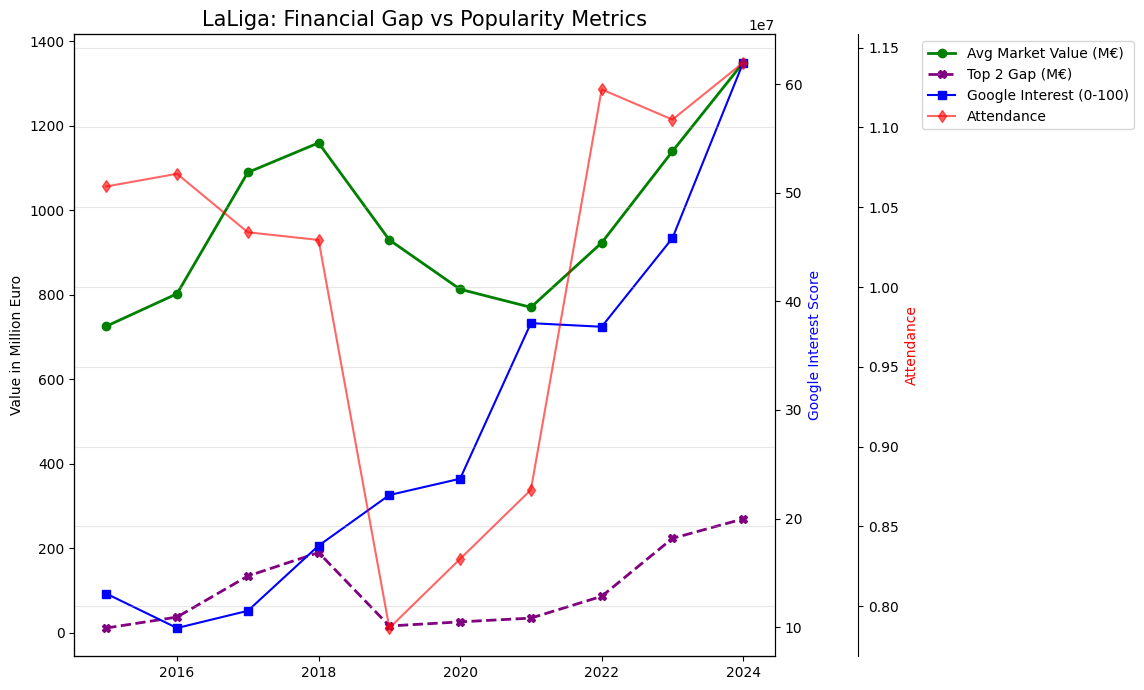

In [8]:
# LaLiga
league_name = 'LaLiga'
l_df = df[df['League'] == league_name].copy()

gap_series = l_df.groupby('Year').apply(calculate_top2_gap)
yearly_df = l_df.drop_duplicates(subset=['Year']).set_index('Year')
yearly_df['Top2_Gap'] = gap_series

fig, ax1 = plt.subplots(figsize=(12, 7))
ln1 = ax1.plot(yearly_df.index, yearly_df['MarketValue_M_Euro'], color='green', marker='o', linewidth=2, label='Avg Market Value (M€)')
ln2 = ax1.plot(yearly_df.index, yearly_df['Top2_Gap'], color='purple', marker='X', linestyle='--', linewidth=2, label='Top 2 Gap (M€)')
ax1.set_ylabel('Value in Million Euro')

ax2 = ax1.twinx()
ln3 = ax2.plot(yearly_df.index, yearly_df['League_Google_Interest'], color='blue', marker='s', label='Google Interest (0-100)')
ax2.set_ylabel('Google Interest Score', color='blue')

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ln4 = ax3.plot(yearly_df.index, yearly_df['League_Avg_Attendance'], color='red', marker='d', alpha=0.6, label='Attendance')
ax3.set_ylabel('Attendance', color='red')

lns = ln1 + ln2 + ln3 + ln4
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', bbox_to_anchor=(1.2, 1))
plt.title(f'{league_name}: Financial Gap vs Popularity Metrics', fontsize=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4140/3037177806.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gap_series = l_df.groupby('Year').apply(calculate_top2_gap)


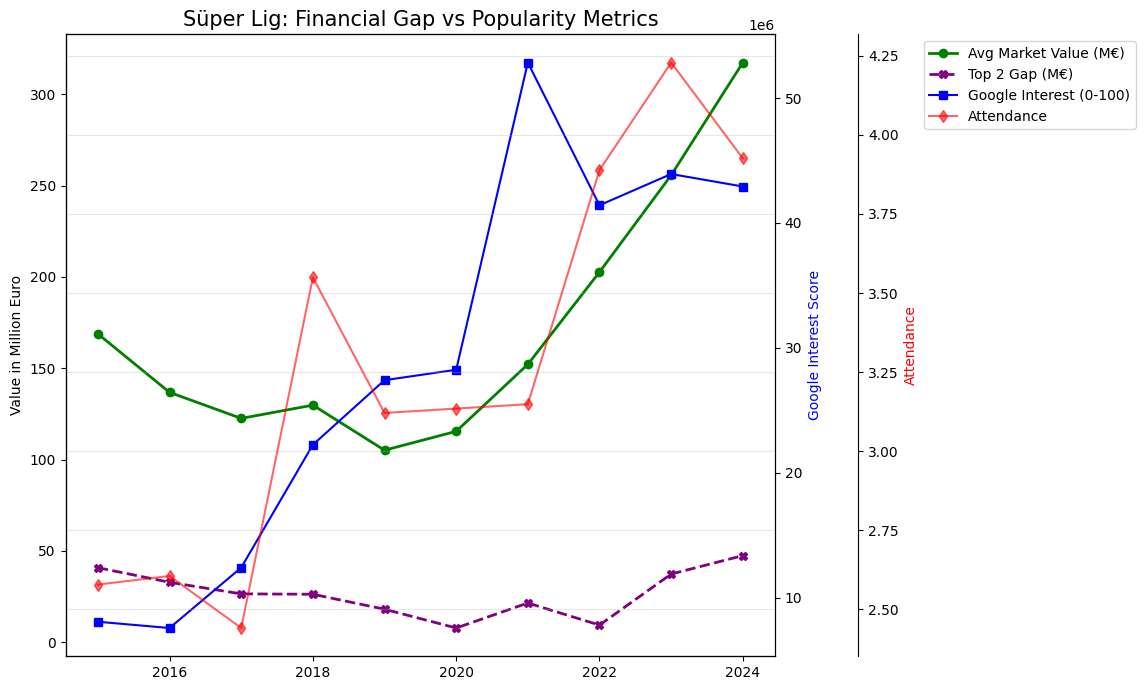

In [9]:
# Süper Lig
league_name = 'Süper Lig'
l_df = df[df['League'] == league_name].copy()

gap_series = l_df.groupby('Year').apply(calculate_top2_gap)
yearly_df = l_df.drop_duplicates(subset=['Year']).set_index('Year')
yearly_df['Top2_Gap'] = gap_series

fig, ax1 = plt.subplots(figsize=(12, 7))
ln1 = ax1.plot(yearly_df.index, yearly_df['MarketValue_M_Euro'], color='green', marker='o', linewidth=2, label='Avg Market Value (M€)')
ln2 = ax1.plot(yearly_df.index, yearly_df['Top2_Gap'], color='purple', marker='X', linestyle='--', linewidth=2, label='Top 2 Gap (M€)')
ax1.set_ylabel('Value in Million Euro')

ax2 = ax1.twinx()
ln3 = ax2.plot(yearly_df.index, yearly_df['League_Google_Interest'], color='blue', marker='s', label='Google Interest (0-100)')
ax2.set_ylabel('Google Interest Score', color='blue')

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ln4 = ax3.plot(yearly_df.index, yearly_df['League_Avg_Attendance'], color='red', marker='d', alpha=0.6, label='Attendance')
ax3.set_ylabel('Attendance', color='red')

lns = ln1 + ln2 + ln3 + ln4
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', bbox_to_anchor=(1.2, 1))
plt.title(f'{league_name}: Financial Gap vs Popularity Metrics', fontsize=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4140/4143948134.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gap_series = l_df.groupby('Year').apply(calculate_top2_gap)


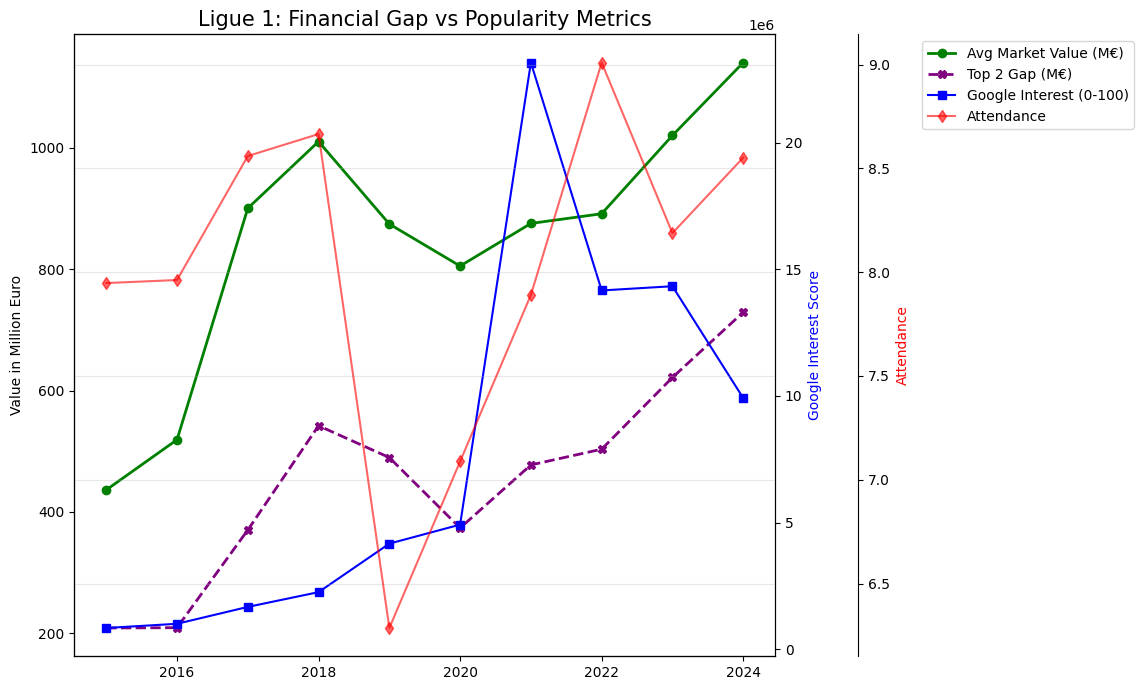

In [10]:
# Ligue 1
league_name = 'Ligue 1'
l_df = df[df['League'] == league_name].copy()

gap_series = l_df.groupby('Year').apply(calculate_top2_gap)
yearly_df = l_df.drop_duplicates(subset=['Year']).set_index('Year')
yearly_df['Top2_Gap'] = gap_series

fig, ax1 = plt.subplots(figsize=(12, 7))
ln1 = ax1.plot(yearly_df.index, yearly_df['MarketValue_M_Euro'], color='green', marker='o', linewidth=2, label='Avg Market Value (M€)')
ln2 = ax1.plot(yearly_df.index, yearly_df['Top2_Gap'], color='purple', marker='X', linestyle='--', linewidth=2, label='Top 2 Gap (M€)')
ax1.set_ylabel('Value in Million Euro')

ax2 = ax1.twinx()
ln3 = ax2.plot(yearly_df.index, yearly_df['League_Google_Interest'], color='blue', marker='s', label='Google Interest (0-100)')
ax2.set_ylabel('Google Interest Score', color='blue')

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ln4 = ax3.plot(yearly_df.index, yearly_df['League_Avg_Attendance'], color='red', marker='d', alpha=0.6, label='Attendance')
ax3.set_ylabel('Attendance', color='red')

lns = ln1 + ln2 + ln3 + ln4
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', bbox_to_anchor=(1.2, 1))
plt.title(f'{league_name}: Financial Gap vs Popularity Metrics', fontsize=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4140/115233869.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gap_series = l_df.groupby('Year').apply(calculate_top2_gap)


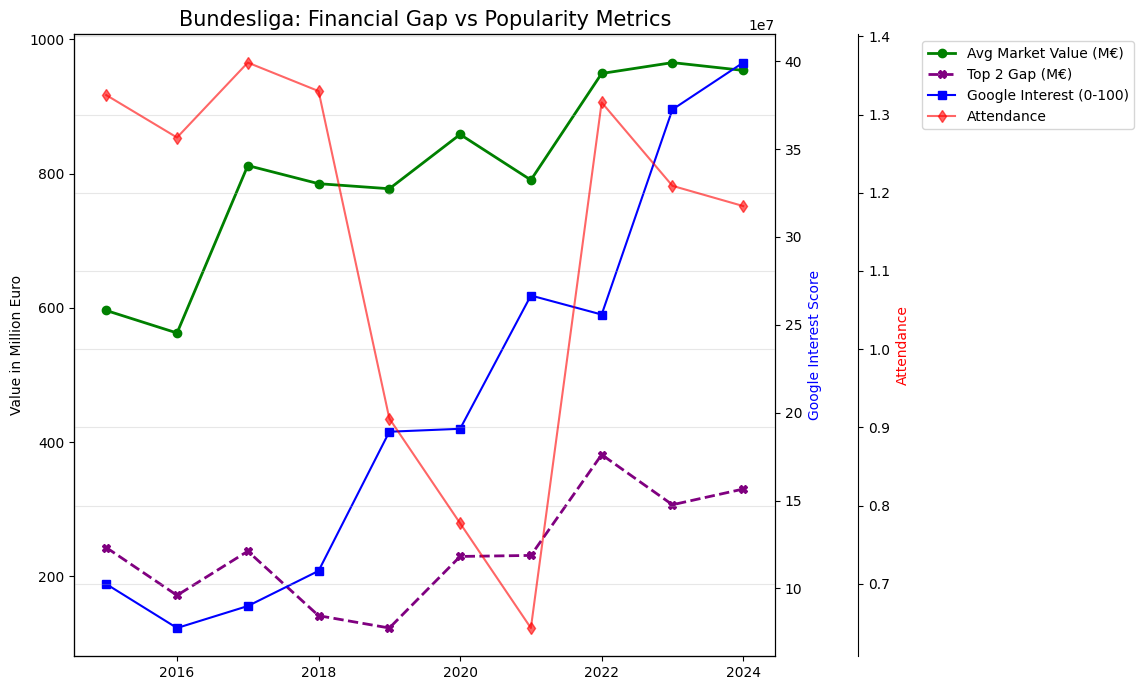

In [11]:
# Bundesliga
league_name = 'Bundesliga'
l_df = df[df['League'] == league_name].copy()

gap_series = l_df.groupby('Year').apply(calculate_top2_gap)
yearly_df = l_df.drop_duplicates(subset=['Year']).set_index('Year')
yearly_df['Top2_Gap'] = gap_series

fig, ax1 = plt.subplots(figsize=(12, 7))
ln1 = ax1.plot(yearly_df.index, yearly_df['MarketValue_M_Euro'], color='green', marker='o', linewidth=2, label='Avg Market Value (M€)')
ln2 = ax1.plot(yearly_df.index, yearly_df['Top2_Gap'], color='purple', marker='X', linestyle='--', linewidth=2, label='Top 2 Gap (M€)')
ax1.set_ylabel('Value in Million Euro')

ax2 = ax1.twinx()
ln3 = ax2.plot(yearly_df.index, yearly_df['League_Google_Interest'], color='blue', marker='s', label='Google Interest (0-100)')
ax2.set_ylabel('Google Interest Score', color='blue')

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ln4 = ax3.plot(yearly_df.index, yearly_df['League_Avg_Attendance'], color='red', marker='d', alpha=0.6, label='Attendance')
ax3.set_ylabel('Attendance', color='red')

lns = ln1 + ln2 + ln3 + ln4
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', bbox_to_anchor=(1.2, 1))
plt.title(f'{league_name}: Financial Gap vs Popularity Metrics', fontsize=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4140/3036124316.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gap_series = l_df.groupby('Year').apply(get_gap)
/tmp/ipykernel_4140/3036124316.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gap_series = l_df.groupby('Year').apply(get_gap)


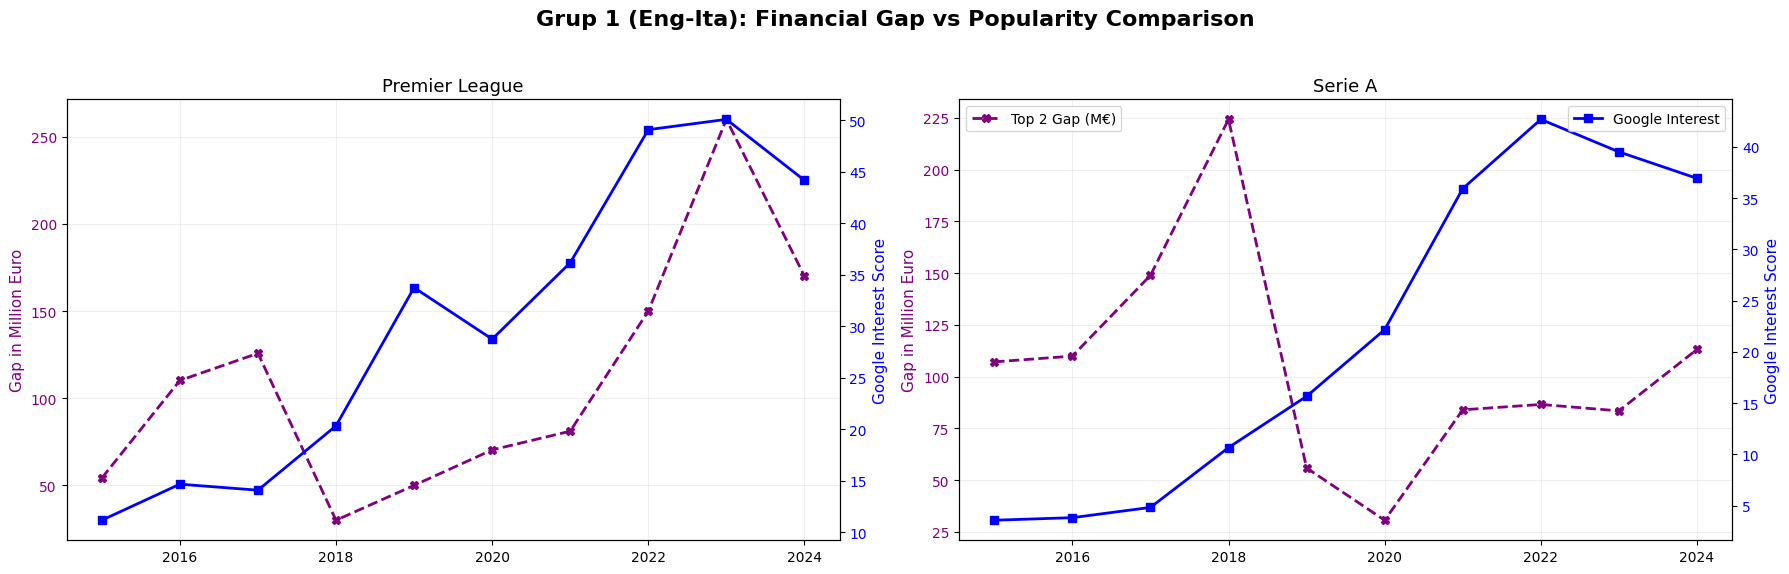

/tmp/ipykernel_4140/3036124316.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gap_series = l_df.groupby('Year').apply(get_gap)
/tmp/ipykernel_4140/3036124316.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gap_series = l_df.groupby('Year').apply(get_gap)


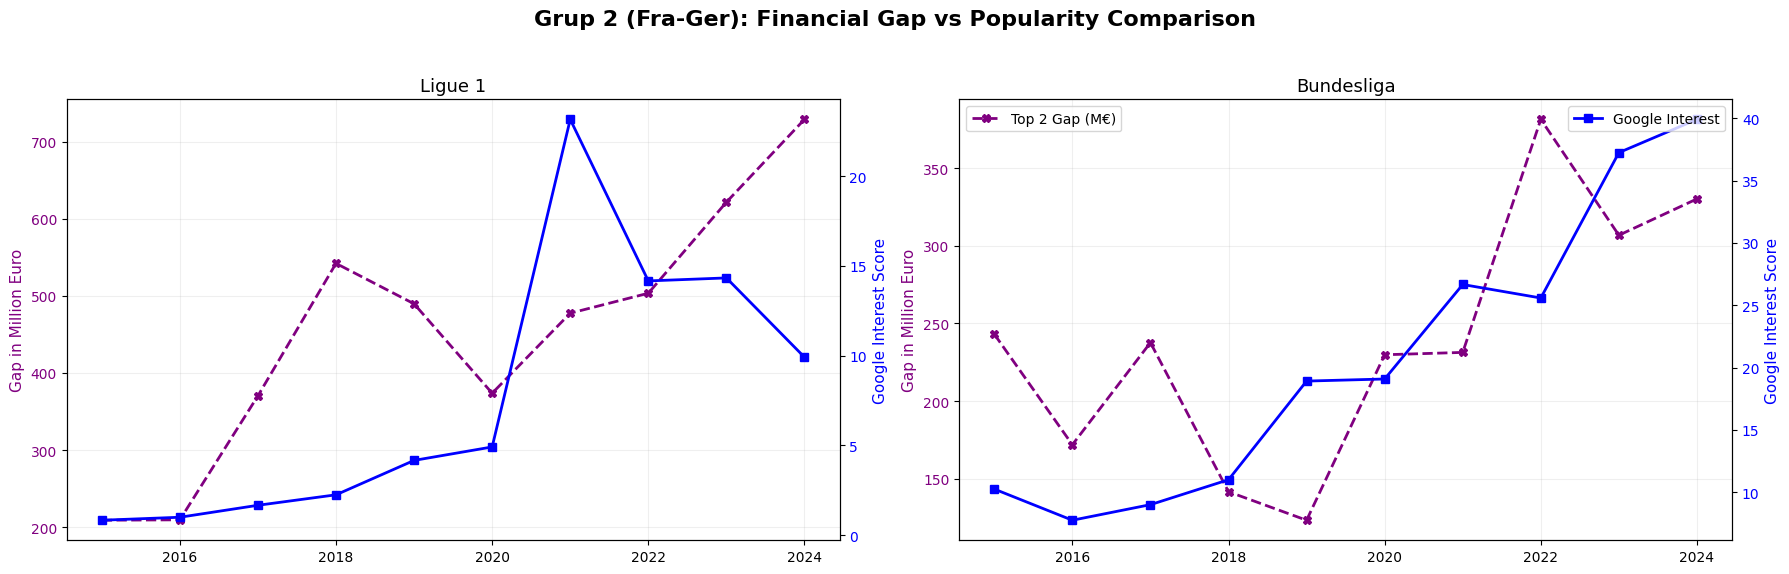

/tmp/ipykernel_4140/3036124316.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gap_series = l_df.groupby('Year').apply(get_gap)
/tmp/ipykernel_4140/3036124316.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gap_series = l_df.groupby('Year').apply(get_gap)


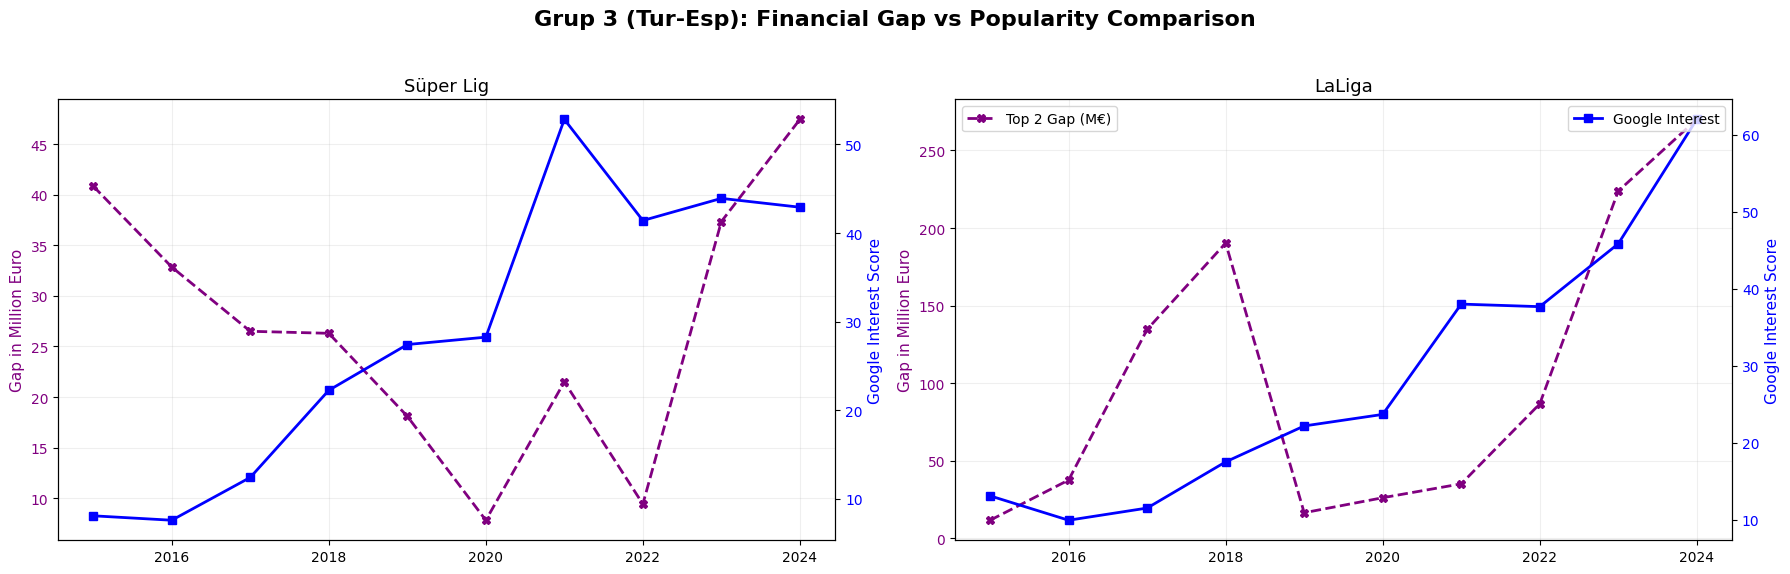

In [12]:
groups = {
    "Grup 1 (Eng-Ita)": ["Premier League", "Serie A"],
    "Grup 2 (Fra-Ger)": ["Ligue 1", "Bundesliga"],
    "Grup 3 (Tur-Esp)": ["Süper Lig", "LaLiga"]
}

def get_gap(group):
    top2 = group.nlargest(2, 'MarketValue_M_Euro')['MarketValue_M_Euro'].values
    return top2[0] - top2[1] if len(top2) > 1 else 0

for group_name, leagues in groups.items():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f'{group_name}: Financial Gap vs Popularity Comparison', fontsize=16, fontweight='bold')

    for i, league in enumerate(leagues):
        current_ax = ax1 if i == 0 else ax2
        l_df = df[df['League'] == league].copy()

        gap_series = l_df.groupby('Year').apply(get_gap)
        yearly_df = l_df.drop_duplicates(subset=['Year']).set_index('Year')
        yearly_df['Top2_Gap'] = gap_series

        color_gap = 'purple'
        current_ax.plot(yearly_df.index, yearly_df['Top2_Gap'], color=color_gap, marker='X', linestyle='--', linewidth=2, label='Top 2 Gap (M€)')
        current_ax.set_ylabel('Gap in Million Euro', color=color_gap, fontsize=11)
        current_ax.tick_params(axis='y', labelcolor=color_gap)
        current_ax.set_title(f'{league}', fontsize=13)

        ax_twin = current_ax.twinx()
        color_int = 'blue'
        ax_twin.plot(yearly_df.index, yearly_df['League_Google_Interest'], color=color_int, marker='s', linewidth=2, label='Google Interest')
        ax_twin.set_ylabel('Google Interest Score', color=color_int, fontsize=11)
        ax_twin.tick_params(axis='y', labelcolor=color_int)

        current_ax.grid(True, alpha=0.2)
        if i == 1:
            current_ax.legend(loc='upper left')
            ax_twin.legend(loc='upper right')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

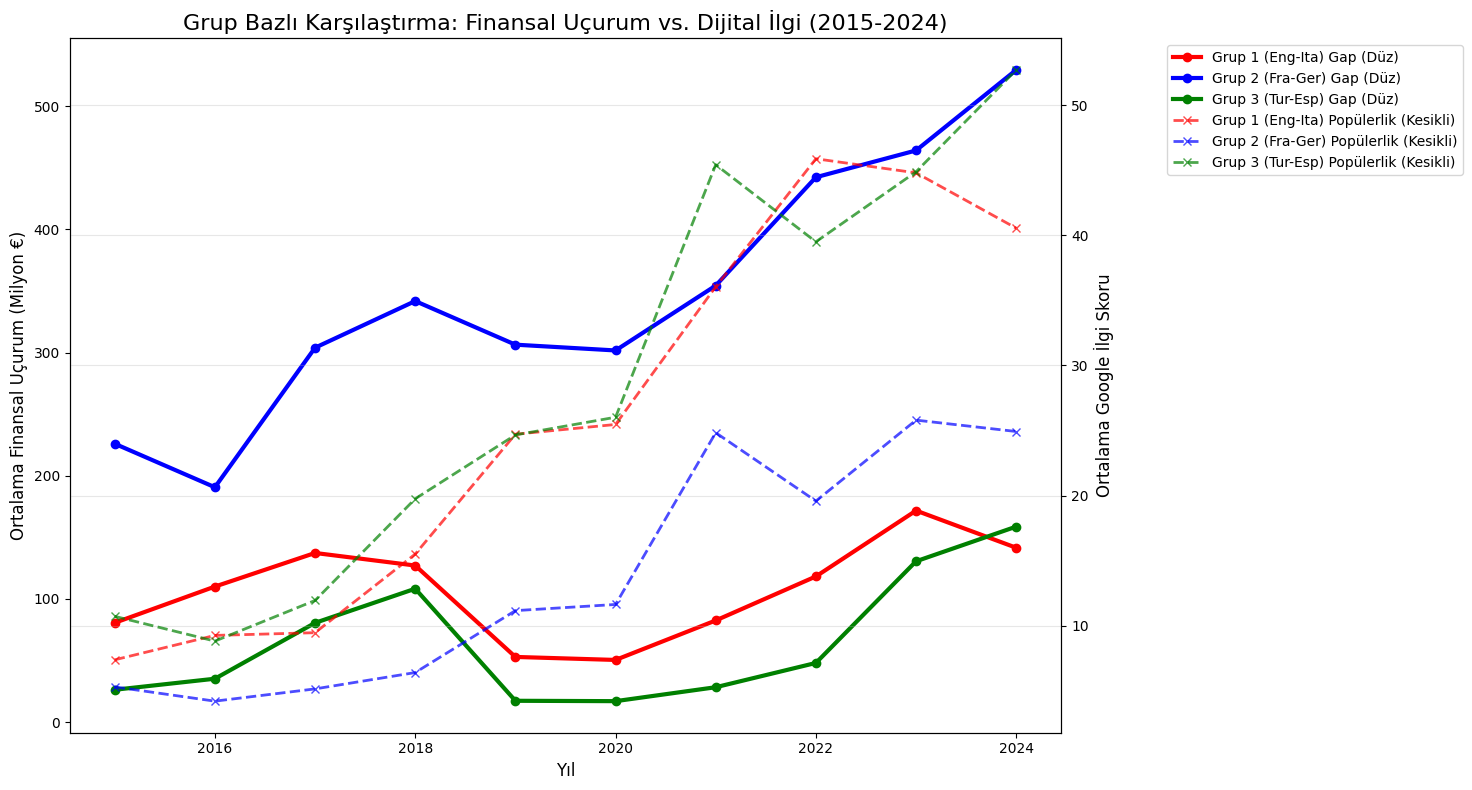

In [13]:
group_definitions = {
    "Grup 1 (Eng-Ita)": {"leagues": ["Premier League", "Serie A"], "color": "red"},
    "Grup 2 (Fra-Ger)": {"leagues": ["Ligue 1", "Bundesliga"], "color": "blue"},
    "Grup 3 (Tur-Esp)": {"leagues": ["Süper Lig", "LaLiga"], "color": "green"}
}

summary_data = []

for g_name, info in group_definitions.items():
    g_df = df[df['League'].isin(info['leagues'])].copy()

    for year in sorted(g_df['Year'].unique()):
        year_df = g_df[g_df['Year'] == year]

        gaps = []
        for l in info['leagues']:
            l_year_df = year_df[year_df['League'] == l]
            top2 = l_year_df.nlargest(2, 'MarketValue_M_Euro')['MarketValue_M_Euro'].values
            if len(top2) > 1:
                gaps.append(top2[0] - top2[1])

        avg_gap = np.mean(gaps) if gaps else 0
        avg_interest = year_df['League_Google_Interest'].mean()

        summary_data.append({
            "Year": year,
            "Group": g_name,
            "Avg_Gap": avg_gap,
            "Avg_Interest": avg_interest,
            "Color": info['color']
        })

plot_df = pd.DataFrame(summary_data)

fig, ax1 = plt.subplots(figsize=(15, 8))
ax2 = ax1.twinx()

for g_name, info in group_definitions.items():
    subset = plot_df[plot_df['Group'] == g_name]

    ax1.plot(subset['Year'], subset['Avg_Gap'], color=info['color'],
             linestyle='-', linewidth=3, marker='o', label=f'{g_name} Gap (Düz)')

    ax2.plot(subset['Year'], subset['Avg_Interest'], color=info['color'],
             linestyle='--', linewidth=2, marker='x', alpha=0.7, label=f'{g_name} Popülerlik (Kesikli)')

ax1.set_xlabel('Yıl', fontsize=12)
ax1.set_ylabel('Ortalama Finansal Uçurum (Milyon €)', fontsize=12)
ax2.set_ylabel('Ortalama Google İlgi Skoru', fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(1.1, 1))

plt.title('Grup Bazlı Karşılaştırma: Finansal Uçurum vs. Dijital İlgi (2015-2024)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()